---
title: "Practice Activity 9.1: Decision Boundaries"
author: Lily
format:
    html:
        embed-resources: true
        code-line-numbers: true
---

**GitHub Repository**: <https://github.com/lilysteinberg/GSB-544---Computing-and-ML/tree/main/Week%208>

## The Data

At this link, you will find a dataset containing information about heart disease patients: https://www.dropbox.com/scl/fi/0vrpdnq5asmeulc4gd50y/ha_1.csv?rlkey=ciisalceotl77ffqhqe3kujzv&dl=1

A description of the original dataset can be found here: https://archive.ics.uci.edu/dataset/45/heart+disease (However, this dataset has been cleaned and reduced, and the people have been given fictious names.)

In [ ]:
# set up data
import pandas as pd
import numpy as np

ha = pd.read_csv('ha_1.csv')

# specify x variables and y variable
X = ha[['age', 'chol']]
y = ha['diagnosis']

## 1. Logistic Regression

Fit a Logistic Regression using only `age` and `chol` (cholesterol) as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

How high for the doctors to estimate a 90% chance that heart disease is present?

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# make pipeline
logistic_pipeline = Pipeline(
  [
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression())
  ]
).set_output(transform="pandas")

# fit
logistic_fitted = logistic_pipeline.fit(X, y)

In [ ]:
logistic_age_coef = logistic_fitted.named_steps['logistic'].coef_[0][0]
logistic_chol_coef = logistic_fitted.named_steps['logistic'].coef_[0][1]
logistic_intercept = logistic_fitted.named_steps['logistic'].intercept_

logistic_age_coef, logistic_chol_coef, logistic_intercept

(np.float64(0.42746115369956383),
 np.float64(0.09597542617159378),
 array([-0.27025982]))

In [ ]:
# .5 = logistic_intercept + logistic_age_coef * 55 + logistic_chol_coef * x
# .5 - logistic_intercept + logistic_age_coef * 55  = logistic_chol_coef * x
# (.5 - logistic_intercept + logistic_age_coef * 55) / logistic_chol_coef = x

(.5 - logistic_intercept + logistic_age_coef * 55) / logistic_chol_coef
# A 55 year old would need to have a cholesterol of 252.99 for drs to predict heart disease is present

(.9 - logistic_intercept + logistic_age_coef * 55) / logistic_chol_coef
# A 55 year old would need to have a cholesterol of 257.16 for drs to predict a 90% chance that heart disease is present

array([257.15565182])

## 2. Linear Discriminant Analysis

Fit an LDA model using only `age` and `chol` (cholesterol)  as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# make pipeline
lda_pipeline = Pipeline(
  [("standardize", StandardScaler()),
  ("lda", LinearDiscriminantAnalysis())]
)

# fit
lda_fitted = lda_pipeline.fit(X, y)

In [ ]:
lda_age_coef = lda_fitted.named_steps['lda'].coef_[0][0]
lda_chol_coef = lda_fitted.named_steps['lda'].coef_[0][1]
lda_intercept = lda_fitted.named_steps['lda'].intercept_

lda_age_coef, lda_chol_coef, lda_intercept

(np.float64(0.4344658185163842),
 np.float64(0.09493491278066943),
 array([-0.26973565]))

In [ ]:
(.5 - lda_intercept + lda_age_coef * 55) / lda_chol_coef
# A 55 year old would need to have a cholesterol of 259.81 for drs to predict heart disease is present

array([259.81332839])

## 3. Support Vector Classifier

Fit an SVC model using only `age` and `chol` as predictors.  Don't forget to tune the regularization parameter.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define parameter grid for tuning regularization parameter C
param_grid = {'svc__C': [0.01, 0.1, 1, 10, 100]}

# make pipeline
svc_pipeline = Pipeline(
  [("standardize", StandardScaler()),
  ("svc", SVC(kernel="linear", probability=True))]
)

svc_pipeline_grid = GridSearchCV(svc_pipeline, param_grid, cv=5)
svc_pipeline_grid.fit(X, y)

# Best fitted pipeline & the SVC inside it
svc_pipeline_best = svc_pipeline_grid.best_estimator_
svc_model_best = svc_pipeline_best.named_steps["svc"]

svc_model_best

# fit
svc_fitted = svc_pipeline_best.fit(X, y)

In [ ]:
svc_age_coef = svc_fitted.named_steps['svc'].coef_[0][0]
svc_chol_coef = svc_fitted.named_steps['svc'].coef_[0][1]
svc_intercept = svc_fitted.named_steps['svc'].intercept_

svc_age_coef, svc_chol_coef, svc_intercept

(np.float64(0.6009556681731714),
 np.float64(0.19360163718551782),
 array([-0.31134524]))

In [ ]:
(.5 - svc_intercept + svc_age_coef * 55) / svc_chol_coef
# A 55 year old would need to have a cholesterol of 174.92 for drs to predict heart disease is present

array([174.91539577])

## 4. Comparing Decision Boundaries

Make a scatterplot of `age` and `chol`, coloring the points by their true disease outcome.  Add a line to the plot representing the **linear separator** (aka **decision boundary**) for each of the three models above.

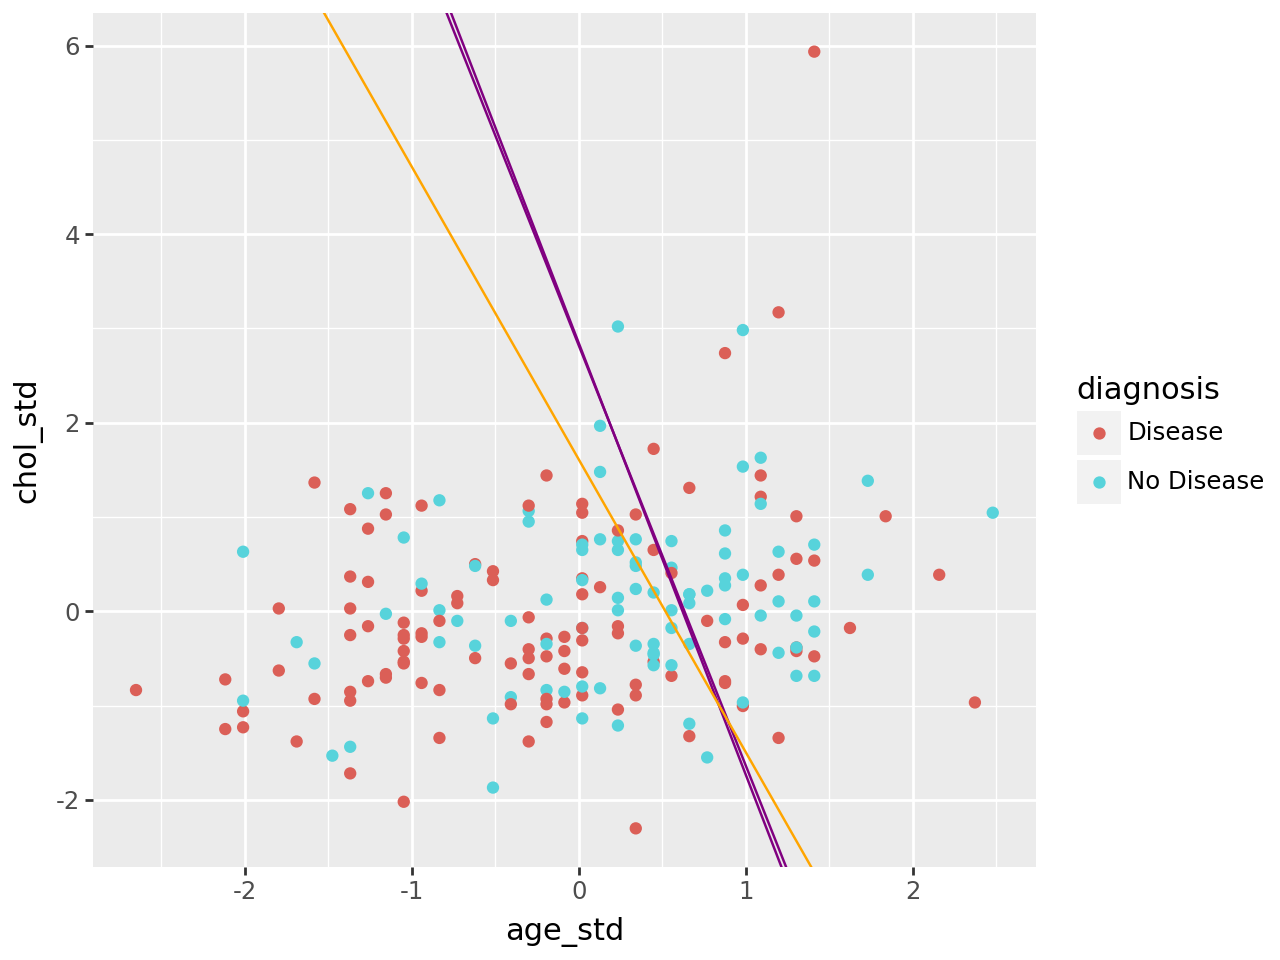

In [ ]:
from plotnine import *

ha["age_std"] = (ha["age"] - ha["age"].mean()) / ha["age"].std()
ha["chol_std"] = (ha["chol"] - ha["chol"].mean()) / ha["chol"].std()

(ggplot(ha, aes(x="age_std", y="chol_std", color="diagnosis"))
+ geom_point()
+ geom_abline(intercept = - logistic_intercept / logistic_chol_coef, slope = - logistic_age_coef / logistic_chol_coef, color = "purple")
+ geom_abline(intercept = - lda_intercept / lda_chol_coef, slope = - lda_age_coef / lda_chol_coef, color = "purple")
+ geom_abline(intercept = - svc_intercept / svc_chol_coef, slope = - svc_age_coef / svc_chol_coef, color = "orange"))